# Coffee Shop ERP — Data Exploration
Quick visual pass over items, costing, and inventory using pandas + matplotlib.

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)

conn = sqlite3.connect('../data/coffee_shop.db')

## 1. Items overview

In [36]:
items = pd.read_sql_query('SELECT * FROM items', conn)
items.groupby('item_type').size().rename('count')

item_type
finished_good     8
intermediate      5
raw_material     15
Name: count, dtype: int64

In [37]:
items[items.item_type == 'finished_good'][['item_code', 'item_name', 'standard_cost', 'sale_price']]

,item_code,item_name,standard_cost,sale_price
20,FG-LATTE-STD,Latte Standard,2.3940,4.50
21,FG-LATTE-SPICED,Spiced Latte,2.9740,5.25
22,FG-LATTE-MOCHA,Mocha Latte,2.8340,5.25
23,FG-BREWED,Brewed Coffee,1.9304,3.00
24,FG-AMERICANO,Americano,1.8160,3.75
25,FG-FRAPPE-CARAMEL,Caramel Frappe,3.4258,5.75
26,FG-FRAPPE-MOCHA,Mocha Frappe,3.3858,5.75
27,FG-COLDBREW,Cold Brew,2.3360,4.25


## 2. Margin by finished good

In [38]:
margin = pd.read_sql_query('SELECT * FROM v_item_margin ORDER BY margin_pct DESC', conn)
margin

,item_id,item_name,sale_price,standard_cost,gross_margin,margin_pct
0,25,Americano,3.75,1.8160,1.9340,0.515733
1,21,Latte Standard,4.50,2.3940,2.1060,0.468000
2,23,Mocha Latte,5.25,2.8340,2.4160,0.460190
3,28,Cold Brew,4.25,2.3360,1.9140,0.450353
4,22,Spiced Latte,5.25,2.9740,2.2760,0.433524
5,27,Mocha Frappe,5.75,3.3858,2.3642,0.411165
6,26,Caramel Frappe,5.75,3.4258,2.3242,0.404209
7,24,Brewed Coffee,3.00,1.9304,1.0696,0.356533


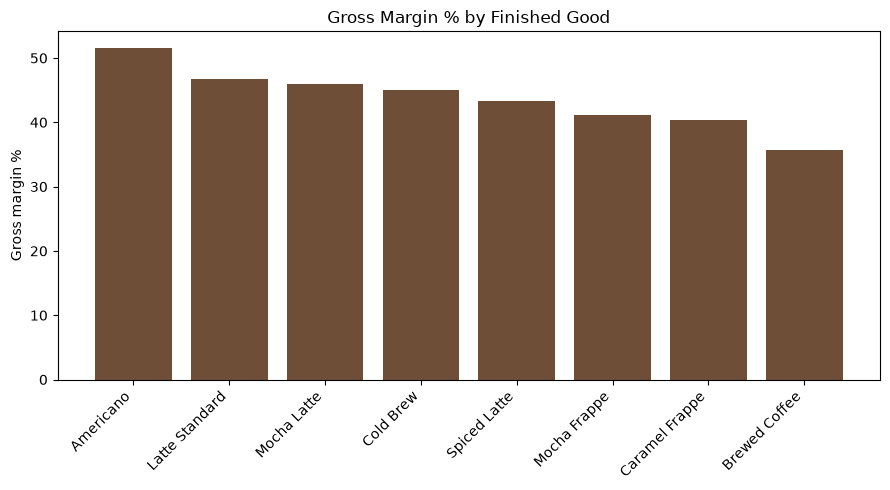

In [39]:
fig, ax = plt.subplots()
ax.bar(margin['item_name'], margin['margin_pct'] * 100, color='#6f4e37')
ax.set_ylabel('Gross margin %')
ax.set_title('Gross Margin % by Finished Good')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

## 3. Cost breakdown: material vs. labor
Uses the same rollup logic as `costing.py`, computed here directly in pandas for exploration.

In [40]:
formulas = pd.read_sql_query('SELECT * FROM formulas', conn)
routes = pd.read_sql_query('SELECT * FROM routes', conn)
route_ops = pd.read_sql_query('SELECT * FROM route_operations', conn)
workstations = pd.read_sql_query('SELECT * FROM workstations', conn)

# labor cost per item: join routes -> route_operations -> workstations
labor = (route_ops.merge(routes, on='route_id')
                   .merge(workstations, on='workstation_id', how='left'))
labor['op_cost'] = (labor['setup_minutes'] + labor['run_minutes']) / 60 * labor['hourly_rate'].fillna(0)
labor_by_item = labor.groupby('item_id')['op_cost'].sum().rename('labor_cost')

# material cost per item: one level of formulas, using items.standard_cost as component cost
# (already rolled up bottom-up by costing.py, so this reflects the full multi-tier BOM)
comp_cost = items.set_index('item_id')['standard_cost']
formulas['component_cost'] = formulas['component_item_id'].map(comp_cost)
formulas['line_cost'] = formulas['quantity'] * (1 + formulas['scrap_pct']) * formulas['component_cost']
material_by_item = formulas.groupby('parent_item_id')['line_cost'].sum().rename('material_cost')

cost_breakdown = (items.set_index('item_id')[['item_code', 'item_type']]
                        .join(material_by_item)
                        .join(labor_by_item)
                        .fillna(0))
cost_breakdown = cost_breakdown[cost_breakdown.item_type.isin(['intermediate', 'finished_good'])]
cost_breakdown = cost_breakdown.sort_values(['item_type', 'material_cost'], ascending=[True, False])
cost_breakdown

,item_code,item_type,material_cost,labor_cost
item_id,,,,
26,FG-FRAPPE-CARAMEL,finished_good,3.1258,0.300
27,FG-FRAPPE-MOCHA,finished_good,3.0858,0.300
23,FG-LATTE-MOCHA,finished_good,2.5340,0.300
22,FG-LATTE-SPICED,finished_good,2.5240,0.450
28,FG-COLDBREW,finished_good,2.3360,0.000
21,FG-LATTE-STD,finished_good,2.2440,0.150
24,FG-BREWED,finished_good,1.9304,0.000
25,FG-AMERICANO,finished_good,1.8160,0.000
20,SFG-COLDBREW,intermediate,1.8360,0.500


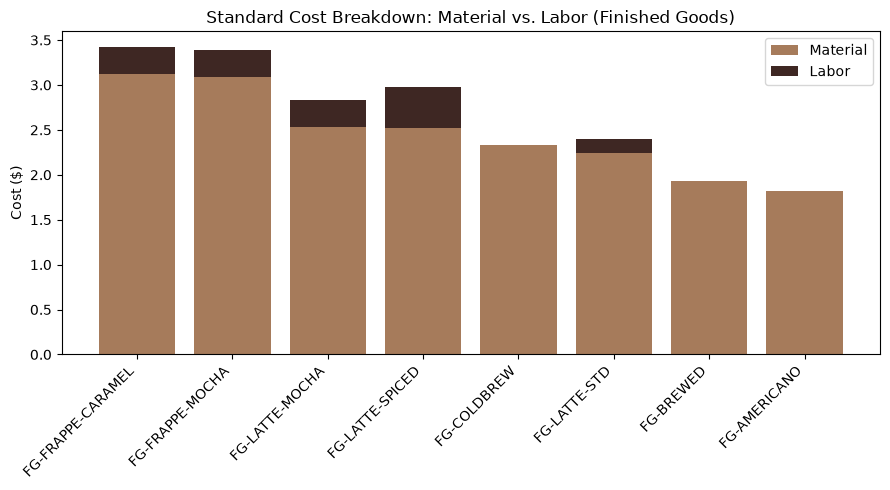

In [41]:
fig, ax = plt.subplots()
fg_breakdown = cost_breakdown[cost_breakdown.item_type == 'finished_good']
cost_breakdown_sorted = fg_breakdown.sort_values('material_cost', ascending=False)
ax.bar(cost_breakdown_sorted['item_code'], cost_breakdown_sorted['material_cost'], label='Material', color='#a67b5b')
ax.bar(cost_breakdown_sorted['item_code'], cost_breakdown_sorted['labor_cost'],
       bottom=cost_breakdown_sorted['material_cost'], label='Labor', color='#3e2723')
ax.set_ylabel('Cost ($)')
ax.set_title('Standard Cost Breakdown: Material vs. Labor (Finished Goods)')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Cost breakdown at the SFG (intermediate) level
This is the cost baked into each base before add-ons/finishing turn it into a sellable finished good.

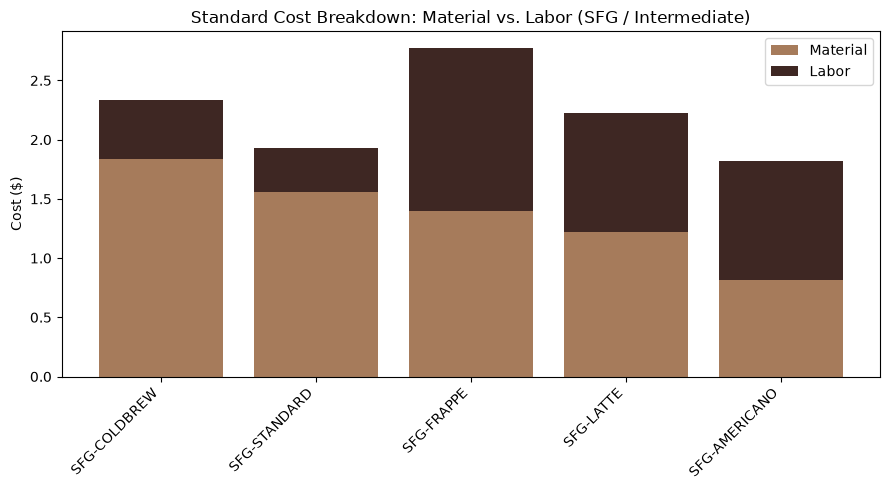

In [42]:
sfg_breakdown = cost_breakdown[cost_breakdown.item_type == 'intermediate'].sort_values('material_cost', ascending=False)

fig, ax = plt.subplots()
ax.bar(sfg_breakdown['item_code'], sfg_breakdown['material_cost'], label='Material', color='#a67b5b')
ax.bar(sfg_breakdown['item_code'], sfg_breakdown['labor_cost'],
       bottom=sfg_breakdown['material_cost'], label='Labor', color='#3e2723')
ax.set_ylabel('Cost ($)')
ax.set_title('Standard Cost Breakdown: Material vs. Labor (SFG / Intermediate)')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Inventory: on-hand vs. reorder point

In [43]:
inv = pd.read_sql_query('''
    SELECT it.item_code, i.on_hand_qty, i.reorder_point, i.reorder_qty, i.pack_size, i.min_order_qty
    FROM inventory i JOIN items it ON it.item_id = i.item_id
    ORDER BY it.item_code
''', conn)
inv

,item_code,on_hand_qty,reorder_point,reorder_qty,pack_size,min_order_qty
0,BASE-BREWED,1280.0,1818.0,1280.0,128.0,1.0
1,BASE-COLDBREW,896.0,1224.0,896.0,128.0,1.0
2,BASE-ESPRESSO,1408.0,1842.0,1408.0,128.0,1.0
3,CREAM-HH,224.0,121.2,224.0,32.0,1.0
4,CREAM-WM,3072.0,1718.4,3072.0,128.0,1.0
5,RM-CARAMELDRIZZLE,60.0,60.0,60.0,20.0,1.0
6,RM-CINNAMON,200.0,150.0,200.0,200.0,1.0
7,RM-COCOA,500.0,600.0,500.0,500.0,1.0
8,RM-ICE,2560.0,678.0,2560.0,320.0,1.0
9,RM-NUTMEG,200.0,150.0,200.0,200.0,1.0


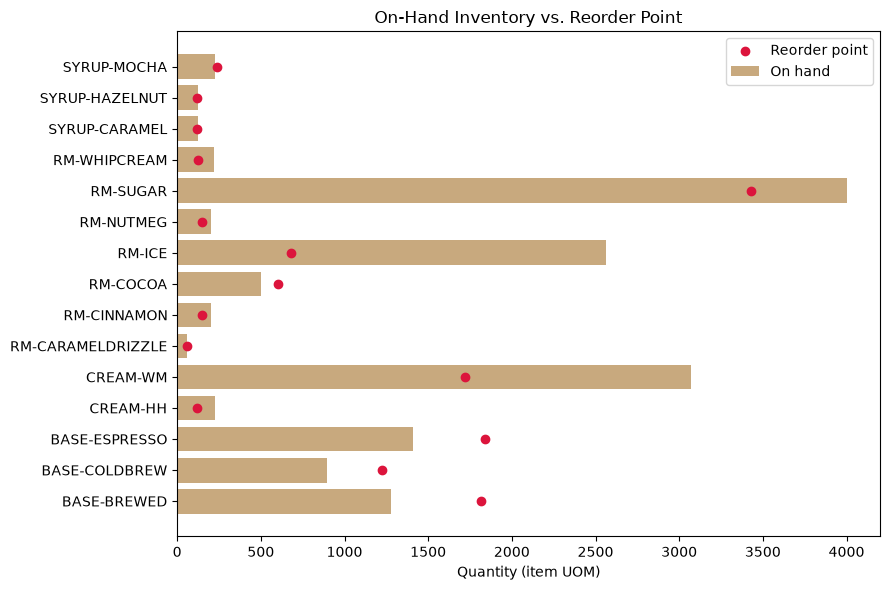

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(inv))
ax.barh(y, inv['on_hand_qty'], color='#c8a97e', label='On hand')
ax.scatter(inv['reorder_point'], y, color='crimson', zorder=3, label='Reorder point')
ax.set_yticks(list(y))
ax.set_yticklabels(inv['item_code'])
ax.set_xlabel('Quantity (item UOM)')
ax.set_title('On-Hand Inventory vs. Reorder Point')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Inventory value by item

In [45]:
inv_value = pd.read_sql_query('SELECT * FROM v_inventory_value ORDER BY inventory_value DESC', conn)
inv_value

,item_id,item_name,on_hand_qty,standard_cost,inventory_value
0,3,Espresso (base),1408.0,0.40,563.20
1,2,Whole Milk,3072.0,0.06,184.32
2,5,Cold Brew (base),896.0,0.20,179.20
3,4,Brewed Coffee (base),1280.0,0.10,128.00
4,7,Mocha Syrup,228.6,0.25,57.15
5,11,Whipped Cream,220.0,0.20,44.00
6,10,Sugar,4000.0,0.01,40.00
7,1,Half & Half,224.0,0.15,33.60
8,6,Hazelnut Syrup,127.0,0.25,31.75
9,8,Caramel Syrup,127.0,0.25,31.75


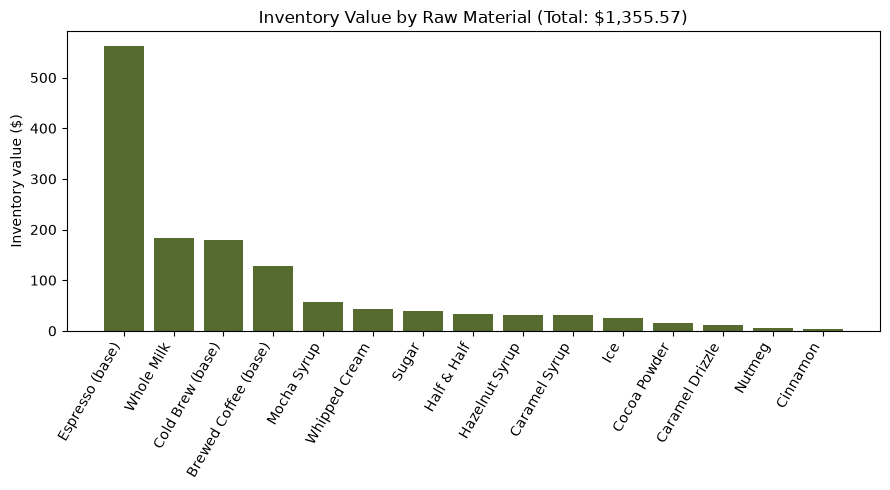

In [46]:
fig, ax = plt.subplots()
ax.bar(inv_value['item_name'], inv_value['inventory_value'], color='#556b2f')
ax.set_ylabel('Inventory value ($)')
ax.set_title(f"Inventory Value by Raw Material (Total: ${inv_value['inventory_value'].sum():,.2f})")
ax.tick_params(axis='x', rotation=60)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

## 6. Orders / financials (once Phase 2+ data exists)
Placeholder cells -- these will populate once `simulate_orders.py` has been run.

In [47]:
orders = pd.read_sql_query('SELECT * FROM orders', conn)
order_lines = pd.read_sql_query('SELECT * FROM order_lines', conn)
print(f'{len(orders)} orders, {len(order_lines)} order lines')
orders.head()

7706 orders, 9175 order lines


,order_id,customer_id,order_date,status
0,1,1,2026-06-03 14:11:00,completed
1,2,32,2026-06-03 18:02:00,completed
2,3,1,2026-06-03 17:14:00,completed
3,4,4,2026-06-03 11:44:00,completed
4,5,32,2026-06-03 09:46:00,completed


In [48]:
conn.close()